### Imports, read in data, add relevant fields

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import glob
import os
import math

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error as mse, classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import export_graphviz, plot_tree


import graphviz

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchcam.methods import GradCAM
from torchvision.transforms.functional import to_pil_image
from torchcam.utils import overlay_mask

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import astropy.time
import astropy.coordinates
from astropy.stats import SigmaClip

from photutils.background import Background2D, MedianBackground, SExtractorBackground


import photometrus_utils as util
import assess_processed_data_util as gen_util
import bogus
from ML_utils import *
import sfft_util




/home/alex/miniconda3/envs/photo310/lib/python3.10/site-packages/sfft/utils/HoughDetection.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
triplets = pd.read_csv("data_results/full_data.csv")
bogus_df = triplets[triplets["bogus"]==1].copy()
real_df = pd.read_csv("data_results/triplets_diff_detected.csv")
print("bogus triplets, real triplets:",len(bogus_df), len(real_df))

triplets = pd.concat([real_df, bogus_df])



bogus triplets, real triplets: 109 77


In [3]:
triplet_df = add_analysis_fields(triplets.copy()) 


no sfft diff path?
Issue with nan or inf positions, wcs error?
68.64677 -12.14069 /mnt/photometry/SN2025vjb/07-21_1784600774.9905894.sfftdiff.fits
Issue with nan or inf positions, wcs error?
0.74262 -33.17308 /mnt/photometry/AT2025adpp/07-21_1784600120.832153.sfftdiff.fits
Issue with nan or inf positions, wcs error?
17.35624 -46.81905 /mnt/photometry/AT2025admf/07-21_1784591076.6639543.sfftdiff.fits
Issue with nan or inf positions, wcs error?
34.19008 -24.09083 /mnt/photometry/AT2025zxf/07-20_1784583901.8382525.sfftdiff.fits
no sfft diff path?


no sfft diff path?
no sfft diff path?


In [4]:

triplets.head()

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,full_name,field,truncated_field,band,chip,...,autoMag_Err_ref,psfMag_Err_ref,aperME_CM_ref,autoMag_ref,psfME_CM_ref,psfMag_ref,aperMag_ref,aperMag_Err_ref,autoME_CM_ref,diff_distance
0,0.0,0.0,0.0,12.0,12,AT2025adpt,field7095-2025-11-13,field7095,J,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.599
1,1.0,1.0,1.0,17.0,17,AT2025admo,field4659-2025-11-13,field4659,J,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.304
2,2.0,2.0,2.0,18.0,18,AT2025admg,field4223-2025-11-13,field4223,J,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.769
3,3.0,3.0,3.0,21.0,21,AT2025adkp,field5349-2025-11-17,field5349,J,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.583
4,4.0,4.0,4.0,26.0,26,AT2025adju,field3217-2025-11-13,field3217,J,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.158


In [5]:
df_keys = ['SNR', 'sci_rms', 'ref_rms', 'sci_mag', 'diff_mag', 'n_neg', 'autoMag', 'aperMag', 'psfMag', 'b', 
           'psf_minus_aper', 'full_name', 'bogus']
triplet_df[df_keys].sort_values('full_name').sort_values('bogus', ascending=False).head(20)


,SNR,sci_rms,ref_rms,sci_mag,diff_mag,n_neg,autoMag,aperMag,psfMag,b,psf_minus_aper,full_name,bogus
268,429.29,4.135309,3.421580,13.375,13.678,0.0,13.335,13.375,14.330,17.929434,0.955,TDE2025chm,1
298,64.77,5.985346,7.841291,16.903,19.735,18.0,16.937,16.903,16.900,-50.134166,-0.003,AT2024abcx,1
261,165.15,3.811087,3.668373,15.384,21.299,15.0,15.384,15.335,17.077,39.225856,1.742,SN2025ihl,1
244,148.73,1.459800,1.519980,15.460,18.141,15.0,15.383,15.554,15.460,-23.331391,-0.094,SN2025tpu,1
245,148.73,1.459800,1.519980,15.460,18.141,15.0,15.383,15.554,15.460,-23.331391,-0.094,SN2025tpu,1
246,148.73,1.459800,1.519980,15.460,18.141,15.0,15.383,15.554,15.460,-23.331391,-0.094,SN2025tpu,1
309,1825.44,3.046666,3.349245,10.222,11.596,17.0,10.222,10.537,10.048,16.988024,-0.489,AT2024dfx,1
308,864.31,2.319129,2.885789,11.421,14.848,23.0,11.377,11.595,11.421,13.084636,-0.174,AT2024dpb,1
307,89.03,3.736871,3.043564,16.298,18.945,27.0,16.273,16.309,16.298,12.324507,-0.011,AT2024erg,1
306,1517.28,3.792510,4.135924,10.547,12.827,20.0,10.529,10.667,10.547,11.068689,-0.120,AT2024fje,1


### Random Forest Classifier

In [6]:
X_cols = ['SNR', 'Elongation', 'sci_rms', 'ref_rms', 'sci_cat_len', 'ref_cat_len', 
                        'sci_mag', 'diff_mag', 'n_neg', 'autoMag', 'aperMag', 'psfMag', 'b', 'psf_minus_aper']

metadata= triplet_df.copy()
X = metadata[X_cols].values
y = metadata['bogus'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:

rf_model = RandomForestRegressor(max_depth=4,
                                n_estimators=100, 
                                random_state=42,
                                 max_features="sqrt")
rf_model.fit(X_train, y_train)

ypred_train = rf_model.predict(X_train)
ypred_test = rf_model.predict(X_test)

print("test mse: ", mse(y_test, ypred_test), "\ntrain mse: ", mse(y_train, ypred_train))
print("\ntest r2", rf_model.score(X_test, y_test), "\ntrain r2: ", rf_model.score(X_train, y_train))
print("Depths:", [estimator.tree_.max_depth for estimator in rf_model.estimators_])



test mse:  0.09368679498779581 
train mse:  0.04597908883476883

test r2 0.6209631316336246 
train r2:  0.8088722083957468
Depths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


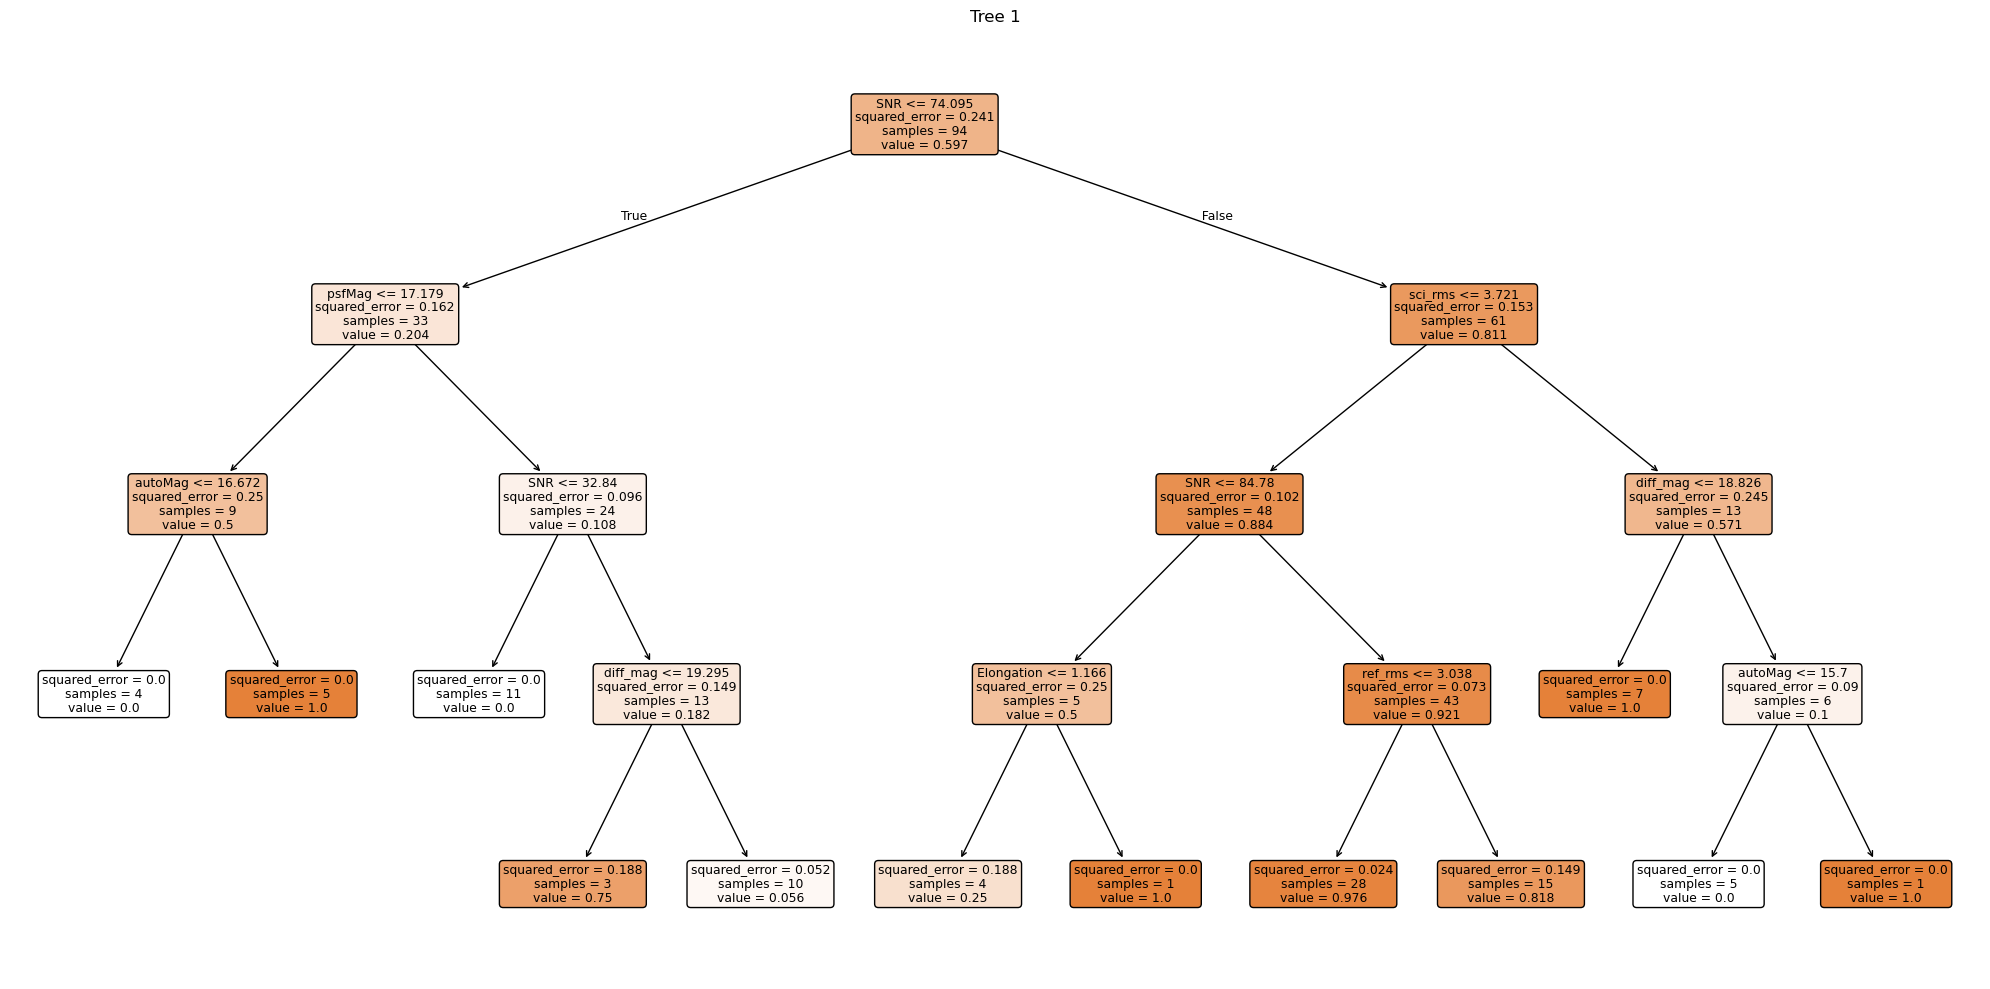

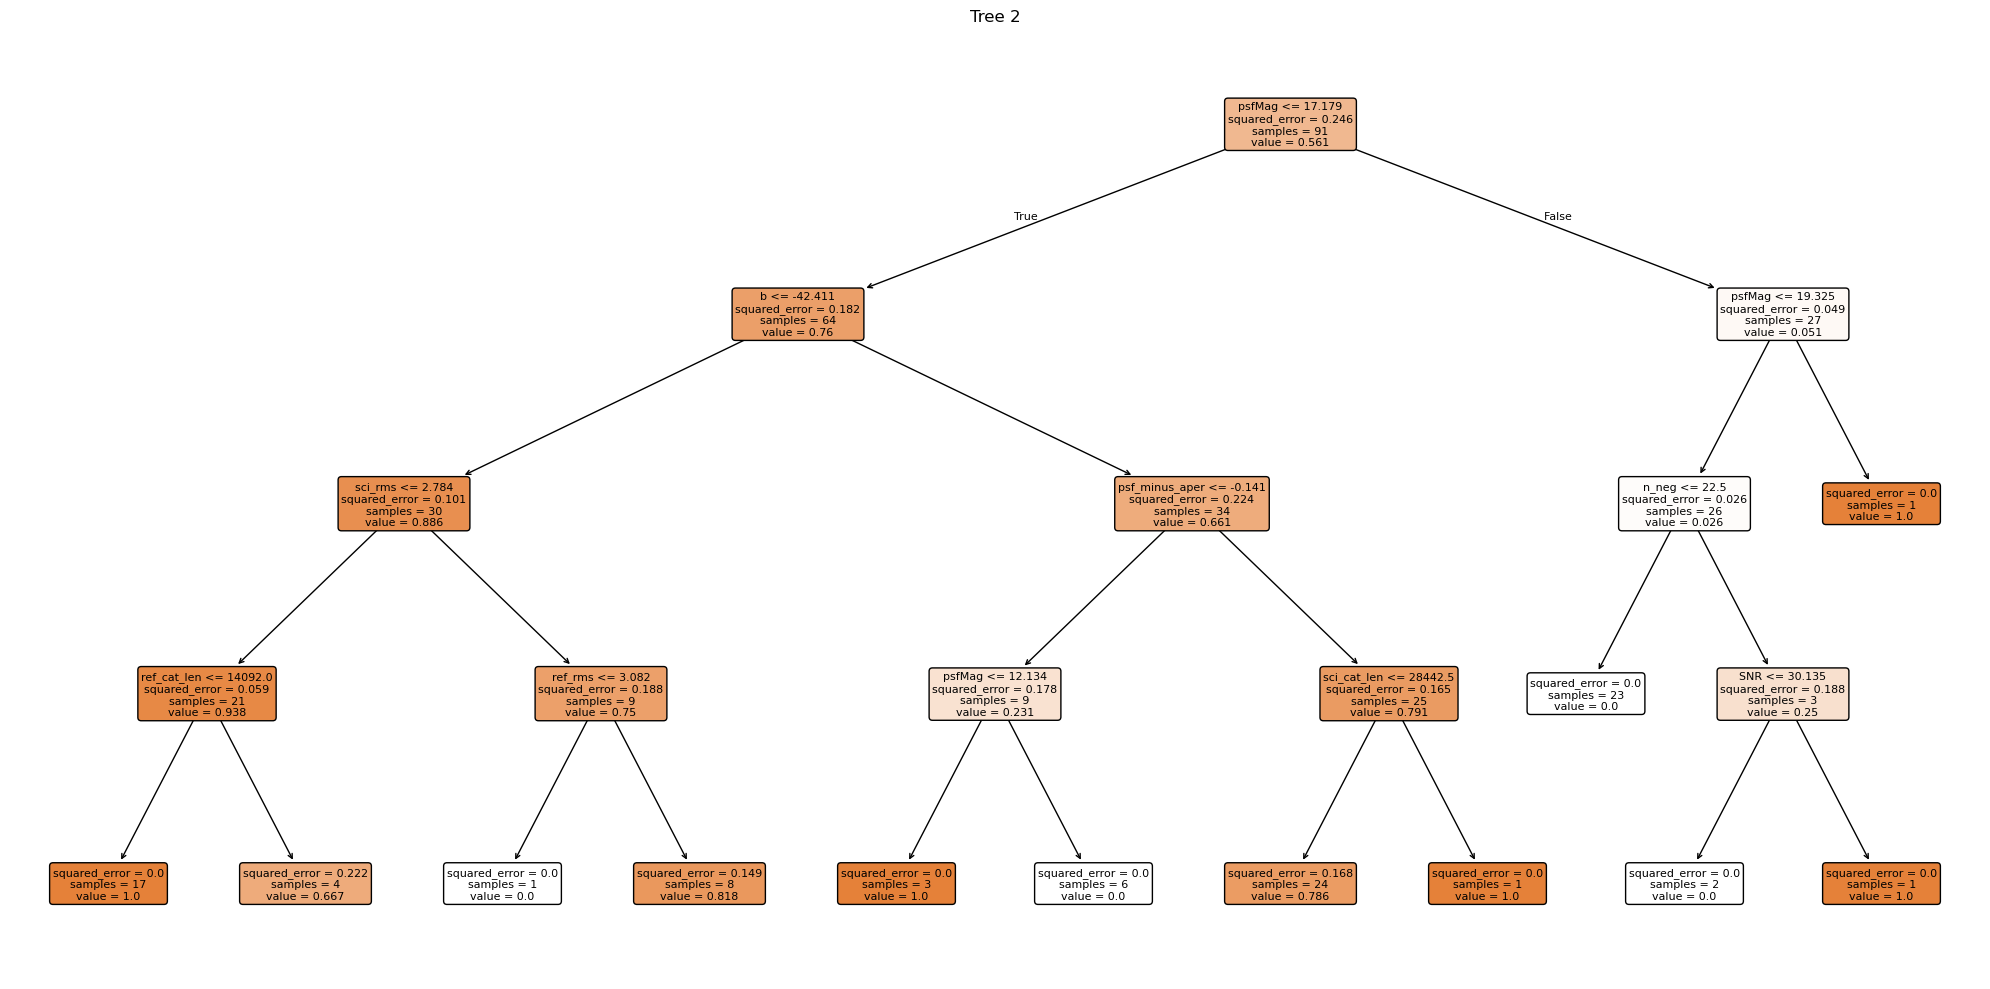

In [8]:
for i, estimator in enumerate(rf_model.estimators_[:2]):
        fig, ax = plt.subplots(figsize=(20, 10))
        plot_tree(estimator,
                  feature_names=X_cols,
                  class_names=['Bogus', 'Real'],
                  filled=True,
                  rounded=True,
                  ax=ax)
        ax.set_title(f"Tree {i+1}")
        plt.tight_layout()
        plt.show()

### Neural Network Classifier

In [12]:
_batch_size = 64

triplet_images = []
for i, row in triplet_df.iterrows():
    print(row['sfft_diff'])
    triplet = cutout([row['coadd_path'], ast.literal_eval(row['ref_coadd_path'])[0], row['sfft_diff']], row['ra'], row['declination'], row['full_name'])
    triplet_images.append(np.nan_to_num(triplet))
    # print(triplet)
    print("read in data for", row['full_name'])



/mnt/photometry/AT2025adpt/07-21_1784599556.3760352.sfftdiff.fits


/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))


read in data for AT2025adpt
/mnt/photometry/AT2025admo/07-21_1784585521.166345.sfftdiff.fits


/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))


read in data for AT2025admo
/mnt/photometry/AT2025admg/07-21_1784602563.318178.sfftdiff.fits


...

/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))


read in data for AT2025adju
nan


/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))
/home/alex/PycharmProjects/prime-photometry-fiona/automated_detection/ML_utils.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 10 already exists
  plt.figure(10, figsize=(8, 8))


OSError: File-like object does not have a 'write' method, required for mode 'ostream'.

<Figure size 800x800 with 0 Axes>

In [ ]:

display_triplet_images(triplet_images)




In [ ]:
print(np.shape(triplet_images))
images = triplet_images

# Split raw data first
n = len(images)
indices = np.arange(n)
rng = np.random.default_rng(42)
rng.shuffle(indices)

n_train = int(0.8 * n)
# n_val = int(0.1 * n)

train_idx = indices[:n_train]
# val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train:] # + n_val:]

train_images, train_labels = [images[i] for i in train_idx], [y[i] for i in train_idx]
val_images = [] # val_images,   val_labels   = [images[i] for i in val_idx],   [y[i] for i in val_idx]
test_images,  test_labels  = [images[i] for i in test_idx],  [y[i] for i in test_idx]


print("# Train, Val, Test (raw):", len(train_images), len(val_images), len(test_images))

# --- 2. Augment ONLY the training set ---
aug_train_images, aug_train_labels = augment_image(train_images, train_labels)  # 16x bulk-up

def prep_batch(image_list, label_list, px=63):
    tensor_batch = torch.tensor(np.stack(image_list)).float()

    # Per-image normalization
    norms = torch.linalg.matrix_norm(tensor_batch, ord='fro', keepdim=True)
    tensor_batch /= norms
    print("Average L2 Norm:", np.average(torch.flatten(norms)))

    tensor_batch = pad_image(tensor_batch, px=px)
    labels = torch.tensor(label_list, dtype=torch.long)
    return tensor_batch, labels

train_tensor, train_labels_t = prep_batch(aug_train_images, aug_train_labels)
# val_tensor,   val_labels_t   = prep_batch(val_images, val_labels)     # no augmentation
test_tensor,  test_labels_t  = prep_batch(test_images, test_labels)   # no augmentation

print("Train shape:", train_tensor.shape)
# print("Val shape:", val_tensor.shape)
print("Test shape:", test_tensor.shape)

# --- 3. Build datasets/loaders ---
train_data = TensorDataset(train_tensor, train_labels_t)
val_data   = [] #TensorDataset(val_tensor, val_labels_t)
test_data  = TensorDataset(test_tensor, test_labels_t)

train_loader = DataLoader(train_data, batch_size=_batch_size, shuffle=True)
# val_loader   = DataLoader(val_data, batch_size=len(val_data), shuffle=False)
test_loader  = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

print("# Train, Val, Test (final):", len(train_data), len(val_data), len(test_data))

In [ ]:


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.kernel = 3
        self.padding = 1

        self.conv1 = nn.Conv2d(3, 12, self.kernel, padding=self.padding)
        self.bn1 = nn.BatchNorm2d(12)
        self.pool = nn.MaxPool2d(4, 4)

        self.conv2 = nn.Conv2d(12, 4, self.kernel, padding=self.padding)
        self.bn2 = nn.BatchNorm2d(4)

        self.fc1 = nn.Linear(4 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

        self.dropout_conv = nn.Dropout(p=0.25)
        self.dropout_fc = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = F.relu(self.fc2(x))
        x = self.dropout_fc(x)
        x = self.fc3(x)
        return x



In [ ]:
def train(_net, _train_loader, _optimizer, _scheduler=None, min_lr=5e-10, epochs=20):
    _net.train()
    criterion=nn.CrossEntropyLoss() # Binary Cross Entropy Loss with Sigmoid

    for epoch in range(epochs):  # loop over the dataset multiple times
        running_loss = 0.0
        total_samples = 0

        for i, (inputs, _labels) in enumerate(_train_loader):  # for batch in data
            _optimizer.zero_grad()

            outputs = _net(inputs)
            loss = criterion(outputs, _labels)
            loss.backward()
            _optimizer.step()

            current_lr = optimizer.param_groups[0]['lr']
            if _scheduler and current_lr > min_lr:
                _scheduler.step()

            # Calculate loss
            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            if i % 2000 == 1999:
                print(f'[{epoch + 1}, {i + 1:5d}] avg batch loss: {loss.item():.3f}')

        epoch_loss = running_loss / total_samples
        if epoch % 10 == 9:
            print(f'Epoch {epoch+1} - CE Train Loss: {epoch_loss:.4f}')

In [ ]:
def test(_net, test_loader, max_examples_per_category=3):
    _net.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []
    all_images = []
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for inputs, _labels in test_loader:
            outputs = _net(inputs)
            loss = criterion(outputs, _labels)
            total_loss += loss.item()
            n_batches += 1
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(_labels.cpu().numpy())
            all_images.extend(inputs.cpu())

    # Report accuracies 
    avg_loss = total_loss / n_batches
    print(f'CE Test loss: {avg_loss:.3f}')
    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("Classification Report:\n", classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    print(f"tn={tn}, fp={fp}, fn={fn}, tp={tp}")

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Bogus"])
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.tight_layout()
    plt.show()

    display_confusion_images(all_preds, all_labels, all_images)


In [ ]:

print("\nMy Net:")
net = Net()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
train(net, train_loader, optimizer, epochs=50)
test(net, test_loader, max_examples_per_category=5)


In [ ]:
triplet_row = triplet_df[triplet_df["full_name"]=="AT2025lbx"]
triplet_row = dict(triplet_row.iloc[0])
print(triplet_row['coadd_path'])


util.make_cutout(triplet_row['sfft_diff'], triplet_row["RA"], triplet_row["DEC"], png=True, display_file=True)
util.display(triplet_row['sfft_diff'])



images_single_coadd = coadd_to_sources(triplet_row) 

n_triplets = len(images_single_coadd)
coadd_tensor, coadd_labels = prep_batch(images_single_coadd, np.ones(n_triplets))
coadd_data = TensorDataset(coadd_tensor, coadd_labels)
coadd_loader = DataLoader(coadd_data, batch_size=n_triplets, shuffle=False)

In [ ]:

test(net, coadd_loader, max_examples_per_category=3)
